# Sprint 4 - Manipulación de Datos II (Sesiones)

En el presente caso de estudio se busca continuar fortaleciendo las competencias relacionadas con la manipulación, exploración y análisis de datos utilizando **Tidyverse**, profundizando en herramientas y procedimientos fundamentales dentro del flujo de trabajo de un proyecto analítico. A través de ejercicios prácticos y del trabajo con conjuntos de datos reales, se pretende consolidar habilidades relacionadas con la carga, transformación, organización y análisis de información estructurada, permitiendo desarrollar una comprensión más sólida sobre cómo extraer conocimiento útil a partir de los datos.

El análisis de datos moderno requiere no solamente la capacidad de programar y manipular información, sino también la habilidad de estructurar adecuadamente un proyecto analítico, comprendiendo cada una de sus etapas y objetivos. Por esta razón, este caso de estudio busca reforzar los principios metodológicos asociados al desarrollo de proyectos de análisis de datos, promoviendo un enfoque organizado y reproducible para la resolución de problemas basados en información. Esto implica trabajar desde la comprensión del contexto y la calidad de los datos hasta la generación de conclusiones e interpretación de resultados.

En esta etapa del aprendizaje, se pone especial énfasis en el uso de estructuras tabulares y operaciones avanzadas de manipulación de datos mediante **Tidyverse**, incluyendo procesos como filtrado, agrupación, agregación, transformación de variables y tratamiento de datos faltantes o inconsistentes. Estas tareas representan actividades habituales dentro de proyectos reales de analítica y ciencia de datos, donde la preparación adecuada de la información constituye una condición indispensable para obtener resultados confiables y relevantes.

Adicionalmente, este caso de estudio introduce una primera aproximación al proceso de visualización de datos mediante el uso del módulo **ggplot**, una de las librerías más utilizadas en el ecosistema del **Tidyverse** para la construcción de gráficos y representaciones visuales. La visualización de datos desempeña un papel fundamental dentro del análisis, ya que permite identificar patrones, tendencias, relaciones y comportamientos que muchas veces no son evidentes únicamente a través de tablas o estadísticas numéricas.

A lo largo de este caso, se explorarán distintos tipos de gráficos básicos orientados a comunicar información de manera clara y efectiva, comprendiendo además criterios elementales de diseño e interpretación visual. La capacidad de representar resultados gráficamente constituye una habilidad esencial dentro de disciplinas como analítica de negocios, inteligencia artificial, investigación aplicada y ciencia de datos, donde la comunicación efectiva de hallazgos resulta tan importante como el análisis mismo.

En conjunto, las actividades planteadas buscan integrar habilidades técnicas de programación, manipulación de datos y visualización, junto con capacidades analíticas y metodológicas necesarias para abordar problemas reales basados en información. De esta manera, podrás avanzar progresivamente hacia la construcción de proyectos analíticos más completos, estructurados y orientados a la generación de conocimiento útil para la toma de decisiones.

## Entendimiento del contexto

La industria del turismo es aquella que se enfoca en traer personas a destinos específicos localizados en zonas geográficas que ofrezcan características escénicas, culturales o naturales altamente demandadas. Esta actividad puede clasificarse en turismo receptivo o emisivo. El primero de estos se enfoca en establecer productos o servicios propios en dichas zonas y buscar clientes alrededor del mundo para ocupar los espacios provistos; por su parte el segundo se especializa en llevar turistas a destinos fuera de sus lugares habituales de residencia, generando un cíclo económico virtuoso.

Visto esto, Metropolitan Touring (en adelante, MT) se constituye en el principal operador de turismo receptivo en Ecuador, Colombia y Perú, teniendo como principal destino a las islas Galápagos cuya fama radica en su valor único en cuanto a diversidad y especialidad biológica y botánica. En consecuencia, la empresa oferta cruceros en aproximadamene 150 salidas anuales de 4 y 6 noches, a las cuales acompaña con la venta de tickets aéreos para conectar a los turistas con los aeropuertos insulares, y otros servicios complementarios como transfers, visitas guiadas y alojamientos para quienes estén interesados.       

Entre los principales canales del venta de MT destacan mayoristas de turismo emisivo y agencias de viaje. Los mayoristas pueden ser de 3 tipos: 

* Charters: Empresas que compran la totalidad de los espacios disponibles en algunas salidas para su posterior reventa.
* FIT: Empresas que se especializan en la reventa a grupos de turistas bajo demanda bajo el esquema *One-Size Fits All*.
* Grupos: Empresas que se especializan en la reventa a grupos de turistas preprogramados (i.e Empresas que mantienen beneficios para sus empleados).

La empresa desea ejecutar análisis estratégicos semanales y mensuales para tomar decisiones en las unidades comercial y de marketing, por lo cual te ha pedido apoyo para la preparación de su información y su posterior análisis en base a preguntas de negocio concretas.

## Entendimiento de los datos

Ante todo, recuerda cargar las librerías que utilizarás en este documento. Importa por tanto **Tidyverse** y además importa **readxl** que cuenta con funcioens para extraer información de archivos excel.

In [1]:
library(tidyverse)
library(readxl)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


MT ha compartido contigo información de sus ventas en el año 2023 para los canales de venta y productos referidos en el apartado anterior. Estos datos están disponibles en el dataset [**ventas2023.txt**](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_analytics/refs/heads/main/datasets/ventas2023.txt). Carga el dataset con la función `read_delim` de **Tidyverse** dado el tipo y separador del archivo archivo.

In [2]:
df_ventas <- read_delim(
    "https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_analytics/refs/heads/main/datasets/ventas2023.txt", 
    delim = "\t",
    col_select = -1 # La primera columna (posicion 0) en el archivo original es un indice de filas
)

New names:
• `` -> `...1`
Rows: 754 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): fecha, canal
dbl (4): tickets_aereos, barco_1, barco_2, otros_servicios

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Estudia la estructura de estos datos.

In [3]:
glimpse(df_ventas)

Rows: 754
Columns: 6
$ fecha           <chr> "01/01/2023", "01/01/2023", "01/01/2023", "02/01/2023"…
$ canal           <chr> "Agencias", "WS - FIT", "WS - Other", "Agencias", "WS …
$ tickets_aereos  <dbl> NA, 0.00000, NA, 17.75046, 21.29301, NA, 5.33122, 12.6…
$ barco_1         <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ barco_2         <dbl> NA, NA, NA, 91.30334, 51.70929, NA, NA, 15.24536, NA, …
$ otros_servicios <dbl> 13.84368, 32.52059, 16.44274, 68.02157, 16.67878, 3.97…


Esta tabla cuenta con 754 registros y 6 columnas descritas a continuación:

* fecha: Fecha en la que se realizó el viaje.
* canal: Tipo de cliente al cual se le vendió uno o más servicios.
* tickets_aereos: Valor de venta en miles de USD por concepto de tickets aéreos.
* barco_1: Valor de venta en miles de USD por concepto de salidas de cruceros en itinerario de 4 noches.
* barco_2: Valor de venta en miles de USD por concepto de salidas de cruceros en itinerario de 6 noches.
* otros_servicios: Valor de venta en miles de USD por concepto de otros servicios menores.

Explora el dataset con el propósito de generar un plan de acción para preparar los datos.

In [4]:
# Generar una muestra de los datos
df_ventas %>%
sample_n(10)

fecha,canal,tickets_aereos,barco_1,barco_2,otros_servicios
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
05/11/2023,WS - FIT,NA,NA,NA,0.11520
24/04/2023,Agencias,1.42341,NA,11.28600,0.84200
10/08/2023,Agencias,NA,NA,NA,0.64000
05/05/2023,WS - FIT,2.23128,14.634,NA,19.18217
02/08/2023,Agencias,NA,NA,NA,0.23040
04/01/2023,Agencias,1.07104,NA,NA,1.76200
29/04/2023,WS - Other,NA,NA,NA,7.96192
23/03/2023,Agencias,NA,NA,NA,6.03586
02/01/2023,WS - FIT,21.29301,NA,51.70929,16.67878


In [5]:
# Mirar las opciones posibles en la columna canal
df_ventas["canal"] %>%
unique()

canal
<chr>
Agencias
WS - FIT
WS - Other
Charter


In [6]:
# Presentar un resumen estadístico de las variables numéricas
df_ventas[c("tickets_aereos", "barco_1", "barco_2", "otros_servicios")] %>% summary()

 tickets_aereos      barco_1           barco_2        otros_servicios  
 Min.   : 0.000   Min.   :  0.000   Min.   :  0.000   Min.   :  0.000  
 1st Qu.: 1.095   1st Qu.:  8.021   1st Qu.:  8.464   1st Qu.:  1.762  
 Median : 2.142   Median : 15.477   Median : 16.083   Median :  7.306  
 Mean   : 4.513   Mean   : 46.144   Mean   : 31.643   Mean   : 11.272  
 3rd Qu.: 4.702   3rd Qu.:101.620   3rd Qu.: 34.188   3rd Qu.: 16.038  
 Max.   :47.326   Max.   :160.375   Max.   :235.915   Max.   :115.831  
 NA's   :267      NA's   :616       NA's   :506       NA's   :9        

In [7]:
# Verificar la existencia de duplicados
sum(duplicated(df_ventas))

[1] 0

**PLAN DE ACCION PARA PREPARACIÓN DE DATOS**

| # | Acción |
| ---- | ---- |
| 1 | Cambiar el tipo de variable de fecha a *datetime*. A partir de esto, extraer nuevas columnas de mes, semana y dia_semana que faciliten la temporalidad en los análisis deseados. |
| 2 | Cambiar los valores de la columna canal de forma que muestren una de las siguientes opciones más acordes al contexto: Charter, FIT, Grupo o Agencias. |
| 3 | Completar valores perdidos en las columnas que muestran ventas. La imputación debería ser por un valor de 0 puesto que se corresponden a ventas por ese valor. |
| 4 | Transformar los valores de venta de miles de USD a USD para una mejor comprensión de los mismos dentro de los futuros análisis. |
| 5 | Generar columnas venta_total, venta_barcos y venta_otros que contengan las ventas agregadas de los servicios correspondientes para cada registro. Esta consolidación facilitará los análisis estratégicos que se deseen realizar. | 

## Preparación de datos

Cambia el tipo de variable de la columna fecha. Considera que los textos de las fechas en la tabla están en el formato *dia/mes/año*.

In [8]:
df_ventas <- df_ventas %>%
mutate(fecha = dmy(fecha))

glimpse(df_ventas)

Rows: 754
Columns: 6
$ fecha           <date> 2023-01-01, 2023-01-01, 2023-01-01, 2023-01-02, 2023-…
$ canal           <chr> "Agencias", "WS - FIT", "WS - Other", "Agencias", "WS …
$ tickets_aereos  <dbl> NA, 0.00000, NA, 17.75046, 21.29301, NA, 5.33122, 12.6…
$ barco_1         <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ barco_2         <dbl> NA, NA, NA, 91.30334, 51.70929, NA, NA, 15.24536, NA, …
$ otros_servicios <dbl> 13.84368, 32.52059, 16.44274, 68.02157, 16.67878, 3.97…


Extrae los componentes de mes, dia de la semana y semana a partir de la columna fecha.

In [9]:
df_ventas <- df_ventas %>%
mutate(mes = month(fecha)) %>%
mutate(dia_semana = wday(fecha)) %>%
mutate(semana = isoweek(fecha))

df_ventas %>% sample_n(5)

fecha,canal,tickets_aereos,barco_1,barco_2,otros_servicios,mes,dia_semana,semana
<date>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2023-11-06,WS - Other,0.00000,NA,NA,14.36959,11,2,45
2023-03-17,Charter,20.24580,150.9408,NA,1.54625,3,6,11
2023-12-31,WS - FIT,NA,NA,NA,5.26950,12,1,52
2023-11-19,WS - FIT,1.13892,NA,NA,20.91791,11,1,46
2023-06-29,WS - Other,NA,NA,NA,13.65446,6,5,26


Tanto el mes como el día de la semana, poseen una representación más semántica. En concreto para el caso de mes, 1 representa Enero, 2 es Febrero, etc. Utiliza una función `join` para hacer que la columna mes sea más semántica. Apóyate con el siguiente dataset auxiliar:

```r
cat_mes <- tibble(
    mes = 1:12,
    mes_nombre = c("01.Ene","02.Feb","03.Mar","04.Abr","05.May","06.Jun","07.Jul","08.Ago","09.Sep","10.Oct","11.Nov","12.Dic")
)
```

In [10]:
# Cargar catálogo de meses
cat_mes <- tibble(
    mes = 1:12,
    mes_nombre = c("01.Ene","02.Feb","03.Mar","04.Abr","05.May","06.Jun","07.Jul","08.Ago","09.Sep","10.Oct","11.Nov","12.Dic")
)

In [11]:
# Unir datasets con join
df_ventas <- df_ventas %>%
left_join(cat_mes, by = "mes")

# Sustituir mes con nombres semanticos
df_ventas <- df_ventas %>%
mutate(mes = mes_nombre, .keep = "unused")

df_ventas %>% count(mes)

mes,n
<chr>,<int>
01.Ene,67
02.Feb,64
03.Mar,63
04.Abr,73
05.May,66
06.Jun,62
07.Jul,62
08.Ago,62
09.Sep,42


Ahora define y utiliza una función para hacer que la columna dia_semana sea más semántica mediante la función `rowwise`. Considera que el día 1 corresponde al Domingo.

In [12]:
# Definir funcion de asignacion de nombres de dias
dia_semantico <- function (x) {
    if (x == 2) {
        return("01.Lun")
    } else if (x == 3) {
        return("02.Mar")
    } else if (x == 4) {
        return("03.Mie")
    } else if (x == 5) {
        return("04.Jue")
    } else if (x == 6) {
        return("05.Vie")
    } else if (x == 7) {
        return("06.Sab")
    } else {
        return("07.Dom")
    }
}

In [13]:
# Aplicar funcion en columna dia_semana
df_ventas <- df_ventas %>%
rowwise() %>%
mutate(dia_semana = dia_semantico(dia_semana)) %>%
ungroup()

df_ventas %>% sample_n(5)

fecha,canal,tickets_aereos,barco_1,barco_2,otros_servicios,mes,dia_semana,semana
<date>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
2023-08-13,WS - FIT,5.72553,27.51194,NA,15.20452,08.Ago,07.Dom,32
2023-04-15,WS - Other,NA,NA,NA,2.56480,04.Abr,06.Sab,15
2023-02-26,Charter,21.48978,101.62000,NA,38.39951,02.Feb,07.Dom,8
2023-06-08,WS - FIT,2.20968,50.26142,NA,0.28000,06.Jun,04.Jue,23
2023-03-26,WS - FIT,0.00000,NA,NA,3.60980,03.Mar,07.Dom,12


Cambia los valores de la columna canal por Charter, FIT, Grupos o Agencias según corresponda.

In [14]:
# Definir funcion de asignacion de nombres correctos
nombres_canal <- function (x) {
    if (x == "WS - FIT") {
        return("FIT")
    } else if (x == "WS - Other") {
        return("Grupos")
    } else {
        return(x)
    }
}

In [15]:
# Aplicar funcion a columna canal
df_ventas <- df_ventas %>%
rowwise() %>%
mutate(canal = nombres_canal(canal)) %>%
ungroup()

df_ventas %>% count(canal)

canal,n
<chr>,<int>
Agencias,170
Charter,41
FIT,336
Grupos,207


Con la función `replace_na`, imputa 0 a los valores ausentes de todas las columnas que representen ventas.

In [16]:
df_ventas <- df_ventas %>%
mutate(tickets_aereos = replace_na(tickets_aereos, 0)) %>%
mutate(barco_1 = replace_na(barco_1, 0)) %>%
mutate(barco_2 = replace_na(barco_2, 0)) %>%
mutate(otros_servicios = replace_na(otros_servicios, 0))

print(colSums(is.na(df_ventas)))

          fecha           canal  tickets_aereos         barco_1         barco_2 
              0               0               0               0               0 
otros_servicios             mes      dia_semana          semana 
              0               0               0               0 


Transforma los valores de la columnas de venta de miles de USD a USD.

In [17]:
df_ventas <- df_ventas %>%
mutate(tickets_aereos = tickets_aereos * 1000) %>%
mutate(barco_1 = barco_1 * 1000) %>%
mutate(barco_2 = barco_2 * 1000) %>%
mutate(otros_servicios = otros_servicios * 1000)

df_ventas[c("tickets_aereos", "barco_1", "barco_2", "otros_servicios")] %>% 
summary()

 tickets_aereos     barco_1          barco_2       otros_servicios 
 Min.   :    0   Min.   :     0   Min.   :     0   Min.   :     0  
 1st Qu.:    0   1st Qu.:     0   1st Qu.:     0   1st Qu.:  1563  
 Median : 1079   Median :     0   Median :     0   Median :  7210  
 Mean   : 2915   Mean   :  8446   Mean   : 10408   Mean   : 11138  
 3rd Qu.: 2806   3rd Qu.:     0   3rd Qu.:  8464   3rd Qu.: 15938  
 Max.   :47326   Max.   :160375   Max.   :235915   Max.   :115831  

Genera las columnas venta_barcos, venta_otros y venta_total que consoliden las ventas por estos servicios según corresponda.

In [18]:
# Crear columna venta_barcos, venta_otros y venta total
df_ventas <- df_ventas %>%
mutate(venta_barcos = barco_1 + barco_2) %>%
mutate(venta_otros = tickets_aereos + otros_servicios) %>%
mutate(venta_total = venta_barcos + venta_otros)

glimpse(df_ventas)

Rows: 754
Columns: 12
$ fecha           <date> 2023-01-01, 2023-01-01, 2023-01-01, 2023-01-02, 2023-…
$ canal           <chr> "Agencias", "FIT", "Grupos", "Agencias", "FIT", "Grupo…
$ tickets_aereos  <dbl> 0.00, 0.00, 0.00, 17750.46, 21293.01, 0.00, 5331.22, 1…
$ barco_1         <dbl> 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, …
$ barco_2         <dbl> 0.00, 0.00, 0.00, 91303.34, 51709.29, 0.00, 0.00, 1524…
$ otros_servicios <dbl> 13843.68, 32520.59, 16442.74, 68021.57, 16678.78, 3979…
$ mes             <chr> "01.Ene", "01.Ene", "01.Ene", "01.Ene", "01.Ene", "01.…
$ dia_semana      <chr> "07.Dom", "07.Dom", "07.Dom", "01.Lun", "01.Lun", "01.…
$ semana          <dbl> 52, 52, 52, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ venta_barcos    <dbl> 0.00, 0.00, 0.00, 91303.34, 51709.29, 0.00, 0.00, 1524…
$ venta_otros     <dbl> 13843.68, 32520.59, 16442.74, 85772.03, 37971.79, 3979…
$ venta_total     <dbl> 13843.68, 32520.59, 16442.74, 177075.37, 89681.08, 397…


¡Listo! el dataset se encuentra limpio para iniciar la etapa de análisis. Concluye finalmente reorganizando la tabla de tal manera que:

* Se excluyan las columnas de tickets_aereos, barco_1, barco_2 y otros_servicios.
* Se reordenen las columnas tal que este sea el orden: canal, fecha, mes, semana, dia_semana, venta_total, venta_barcos, venta_otros.

In [19]:
# Eliminar columnas que ya no se utilizarán
df_ventas_final <- df_ventas %>%
select(
    -tickets_aereos,
    -barco_1,
    -barco_2,
    -otros_servicios
)

glimpse(df_ventas_final)

Rows: 754
Columns: 8
$ fecha        <date> 2023-01-01, 2023-01-01, 2023-01-01, 2023-01-02, 2023-01-…
$ canal        <chr> "Agencias", "FIT", "Grupos", "Agencias", "FIT", "Grupos",…
$ mes          <chr> "01.Ene", "01.Ene", "01.Ene", "01.Ene", "01.Ene", "01.Ene…
$ dia_semana   <chr> "07.Dom", "07.Dom", "07.Dom", "01.Lun", "01.Lun", "01.Lun…
$ semana       <dbl> 52, 52, 52, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ venta_barcos <dbl> 0.00, 0.00, 0.00, 91303.34, 51709.29, 0.00, 0.00, 15245.3…
$ venta_otros  <dbl> 13843.68, 32520.59, 16442.74, 85772.03, 37971.79, 3979.76…
$ venta_total  <dbl> 13843.68, 32520.59, 16442.74, 177075.37, 89681.08, 3979.7…


In [20]:
# Reordenar columnas 
df_ventas_final <- df_ventas_final %>%
select(
    canal,
    fecha,
    mes,
    semana,
    dia_semana,
    venta_total,
    venta_barcos,
    venta_otros
)

df_ventas_final %>% sample_n(10)

canal,fecha,mes,semana,dia_semana,venta_total,venta_barcos,venta_otros
<chr>,<date>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
FIT,2023-05-10,05.May,19,03.Mie,31515.28,16330.93,15184.35
FIT,2023-06-29,06.Jun,26,04.Jue,295.00,0.00,295.00
FIT,2023-06-12,06.Jun,24,01.Lun,43008.17,0.00,43008.17
Grupos,2023-07-07,07.Jul,27,05.Vie,60377.51,53184.41,7193.10
FIT,2023-05-01,05.May,18,01.Lun,33872.01,13189.30,20682.71
FIT,2023-10-16,10.Oct,42,01.Lun,13801.45,0.00,13801.45
FIT,2023-04-23,04.Abr,16,07.Dom,14987.23,0.00,14987.23
Agencias,2023-01-06,01.Ene,1,05.Vie,18427.46,2957.14,15470.32
Grupos,2023-07-26,07.Jul,30,03.Mie,52367.94,0.00,52367.94


## Análisis de datos

Recuerda que para un correcto análisis vale que tengas siempre en cuenta lo siguiente:

* Su propósito fundamental es **responder preguntas de negocio**, por lo que siempre debes buscar dar soluciones concretas en base a tus resultados.
* No se limita a realizar gráficos o tablas resumen, sino a generar **conclusiones** que aporten valor a partir de estas visualizaciones.
* Debe mantener un **hilo de ideas** conductor lo cual implica orden y consistencia entre los resultados.

Ahora bien, las unidades comerciales y de marketing de MT te plantean las siguientes preguntas:

### ¿Cuál ha sido el comportamiento semanal de las ventas totales?

Para realizar una correcta visualización que responda una pregunta de negocio conviene que sigas estos pasos:

1. Agrega adecuadamente los datos definiendo una métrica o indicador relevante, las variables de agrupamiento y los filtros pertinentes.
2. Evalúa si el resultado de la agregación a modo de tabla es suficiente para responder la pregunta de negocio o un gráfico resultaría más claro y entendible.
3. Si según tu criterio, un gráfico ayúda más a responder la pregunta, créalo de forma simple sin preocuparte por ahora de los aspectos formales del mismo.
4. Genera las conclusiones correspondientes.
5. Regresa al gráfico o tabla creado y aplica los aspectos formales que consideres pertinentes. Al respecto, si deseas dominar las capacidades detrás de las visualizaciones con **Matplotlib**, te sugiero mirar las [galerías](https://matplotlib.org/stable/gallery/index.html) de muestra de la librería.

Agrega entonces los datos de una forma pertinente. Recuerda usar funciones como `group_by`, `summarise` o `pivot_wider`. 

In [21]:
vta_sem <- df_ventas_final %>%
group_by(semana) %>%
summarise(venta_total = sum(venta_total)) %>%
ungroup()

vta_sem

semana,venta_total
<dbl>,<dbl>
1,777941.17
2,392163.91
3,533500.01
4,588888.76
5,429178.27
6,558930.73
7,557427.69
8,594065.62
9,295739.27


Si bien la tabla obtenida muestra los resultados deseados, existe mucha información en el sentido que hay 52 semanas, lo cual dificulta la interpretación acerca del comportamiento de ventas. Entonces, vale que realices un gráfico mediante la función `ggplot`.

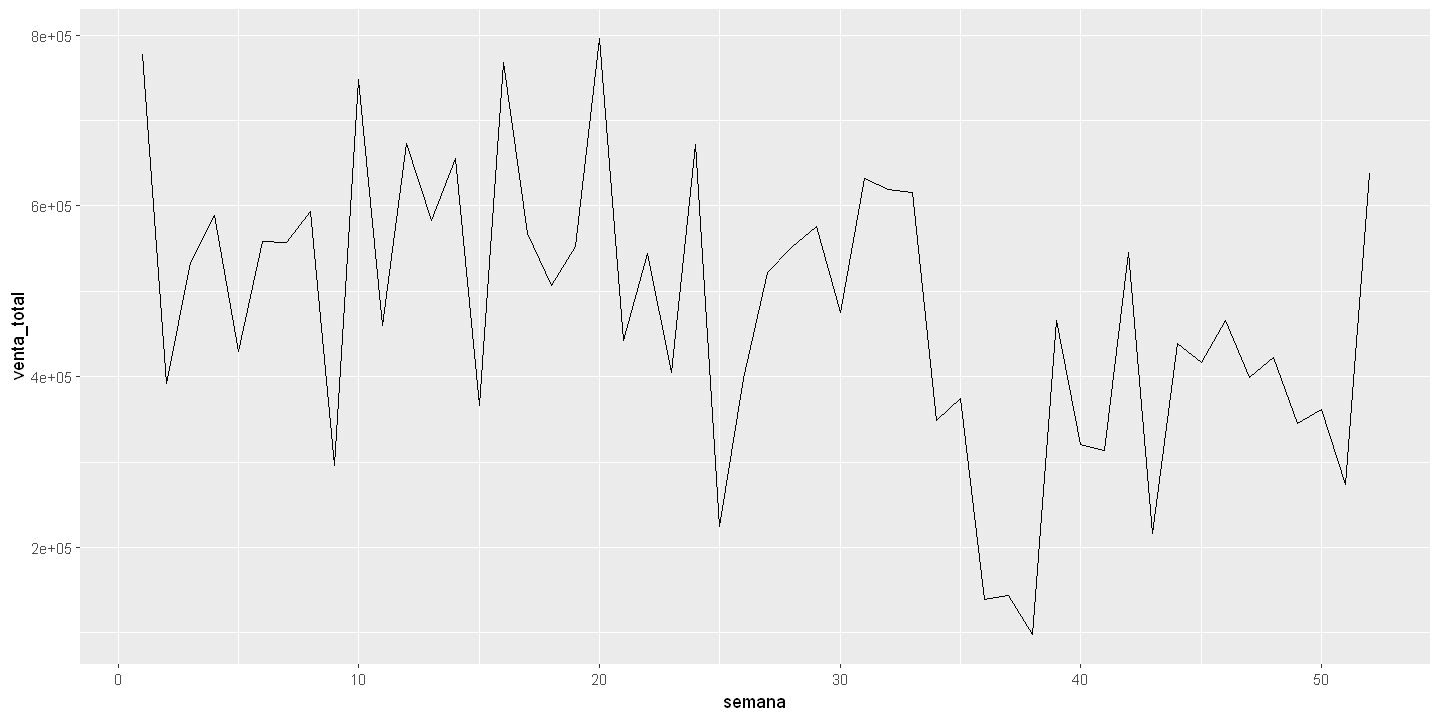

In [22]:
options(repr.plot.width = 12, repr.plot.height = 6) # Esto solamente es para que la visualización se ajuste en jupyter notebook
ggplot(
    data = vta_sem, 
    mapping = aes(
        x = semana,
        y = venta_total
    )
) +
geom_line()

Proporciona al menos dos conclusiones relevantes.

**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | Las ventas totales de MT se reducen significativamente entre las semanas 35 a 40 debido a que las mismas corresponden al final del período de vacaciones (Ago - Sep). En estas fechas el tiempo invertido en servicios recreativos -como el turismo- se reduce significativamente, debido a algunos factores como el inicio de clases en institutos y universidades, así como a la necesidad de ahorro para afrontar fechas importantes posteriores en el año como es la navidad. |
| 2 | Se observan mayores ventas entre las semanas 10 a 20, las cuales corresponden aproximadamente a los meses de marzo y abril. Esto se explica porque en estas fechas muchos países tienen vacaciones asociadas a la Semana Santa o el inicio de la primavera (Hemisferio Norte) y los turistas aprovechan estos feriados para viajar. Lo expuesto permitiría inferir además que un grupo significativo de pasajeros de MT proviene de países como Estados Unidos en donde el *Spring Brake* es un momento importante para visitar otras zonas geográficas. | 

Finalmente repite el gráfico con los aspectos formales que estimes necesarios. Utiliza para estos distintos argumentos y funciones del módulo **ggplot2**.

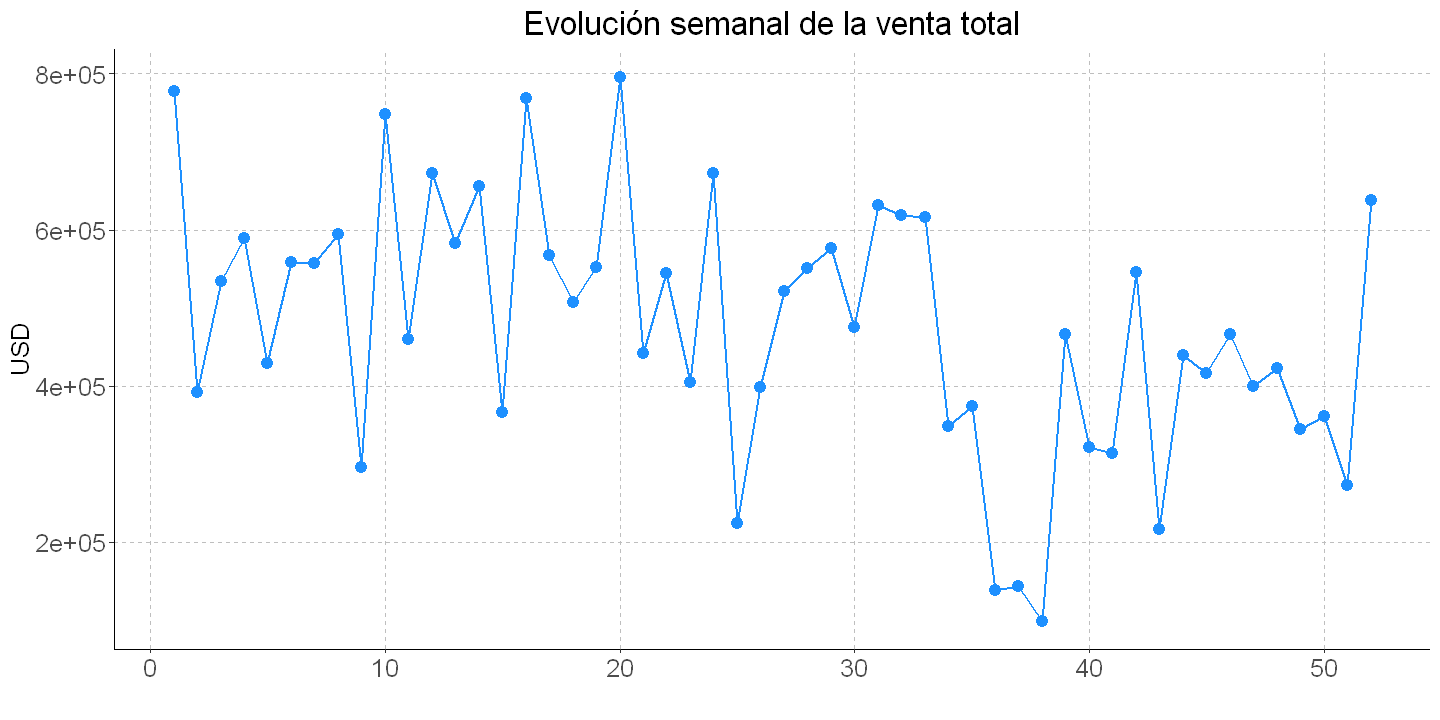

In [23]:
ggplot(
    data = vta_sem, 
    mapping = aes(
        x = semana,
        y = venta_total
    )
) +
geom_line(
    color = "dodgerblue",
    linewidth = 0.75
) +
geom_point(
    color = "dodgerblue",
    size = 3
) +
labs(
    title = "Evolución semanal de la venta total",
    x = "",
    y = "USD"
) +
theme_classic() +
theme(
    panel.grid.major = element_line(color = "gray", linetype = "dashed"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15)
)

### ¿Cuál es la venta promedio de barcos cada día de la semana?

Sigue los mismos pasos de la pregunta anterior para dar una respuesta satisfactoria.

In [24]:
# Agregar los datos
vta_dia <- df_ventas_final %>%
group_by(dia_semana) %>%
summarise(venta_barcos = mean(venta_barcos)) %>%
ungroup()

vta_dia

dia_semana,venta_barcos
<chr>,<dbl>
01.Lun,11989.320
02.Mar,13488.948
03.Mie,7286.292
04.Jue,22508.218
05.Vie,35103.379
06.Sab,26083.213
07.Dom,9010.734


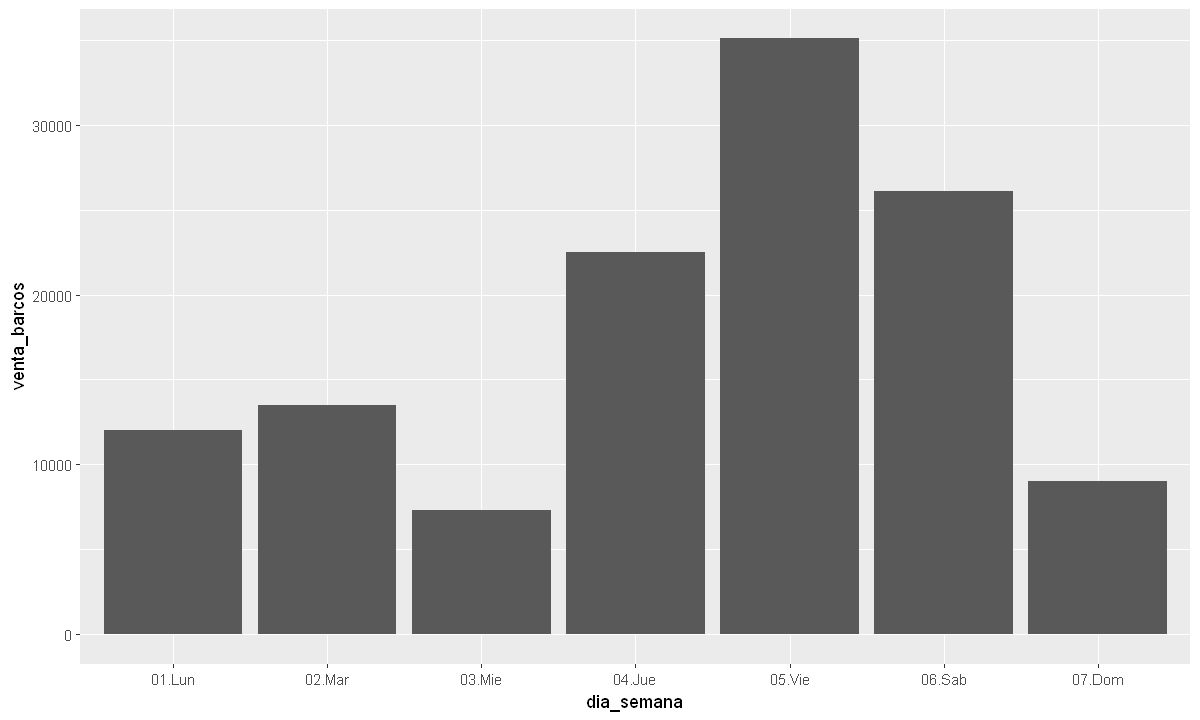

In [25]:
# Crear gráfico simple
options(repr.plot.width = 10, repr.plot.height = 6)
ggplot(
    data = vta_dia, 
    mapping = aes(
        x = dia_semana,
        y = venta_barcos
    )
) +
geom_col()

**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | La venta promedio de barcos en la empresa es mayor los días viernes y sábado, lo cual es coherente en cuanto a que los turistas tienden a preferir viajes que se superpongan con los fines de semana para minimizar los días que toman libres en sus trabajos. Esto se complementa también cuando se evidencia una menor venta en los días miércoles (mitad de semana laborable) y domingo (retorno para prepararse para el trabajo). |

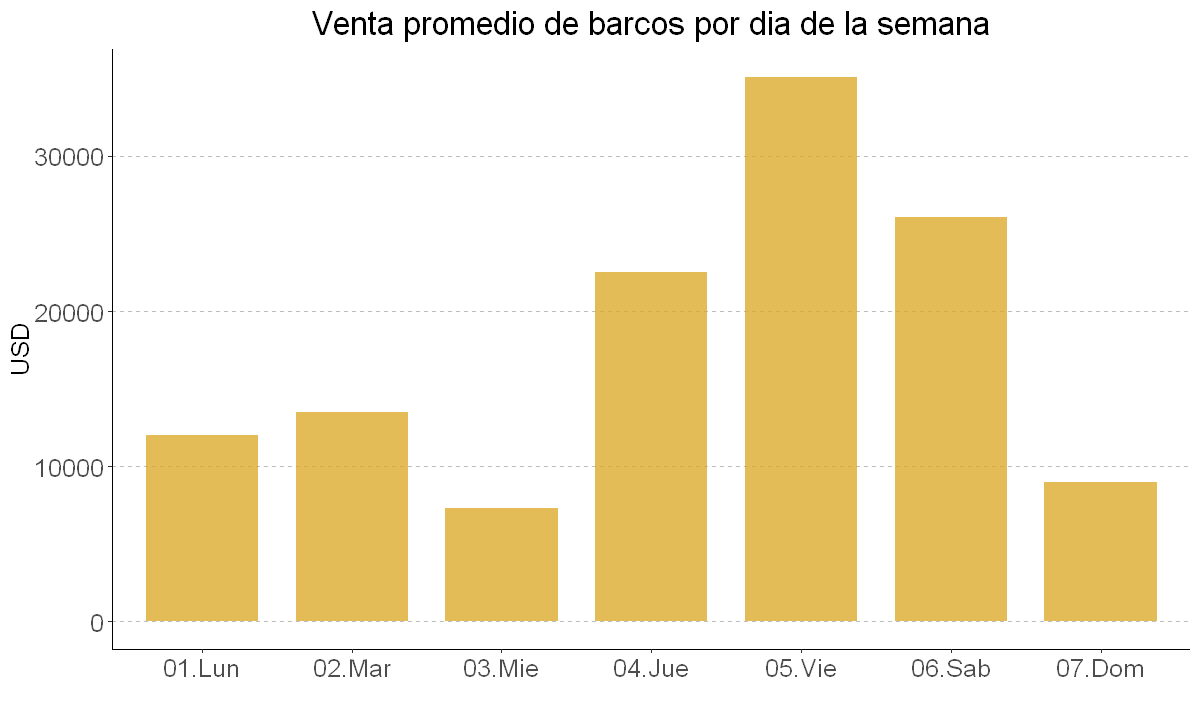

In [26]:
# Incorporar formato a grafico
ggplot(
    data = vta_dia, 
    mapping = aes(
        x = dia_semana,
        y = venta_barcos
    )
) +
geom_col(
    fill = "goldenrod",
    alpha = 0.75,
    width = 0.75
) +
labs(
    title = "Venta promedio de barcos por dia de la semana",
    x = "",
    y = "USD"
) +
theme_classic() +
theme(
    panel.grid.major.y = element_line(color = "gray", linetype = "dashed"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15)
)

### ¿Cómo se comportan las ventas por canal?

In [27]:
# Agregar datos
vta_canal <- df_ventas_final %>%
group_by(canal) %>%
summarise(venta_total = sum(venta_total)) %>%
ungroup

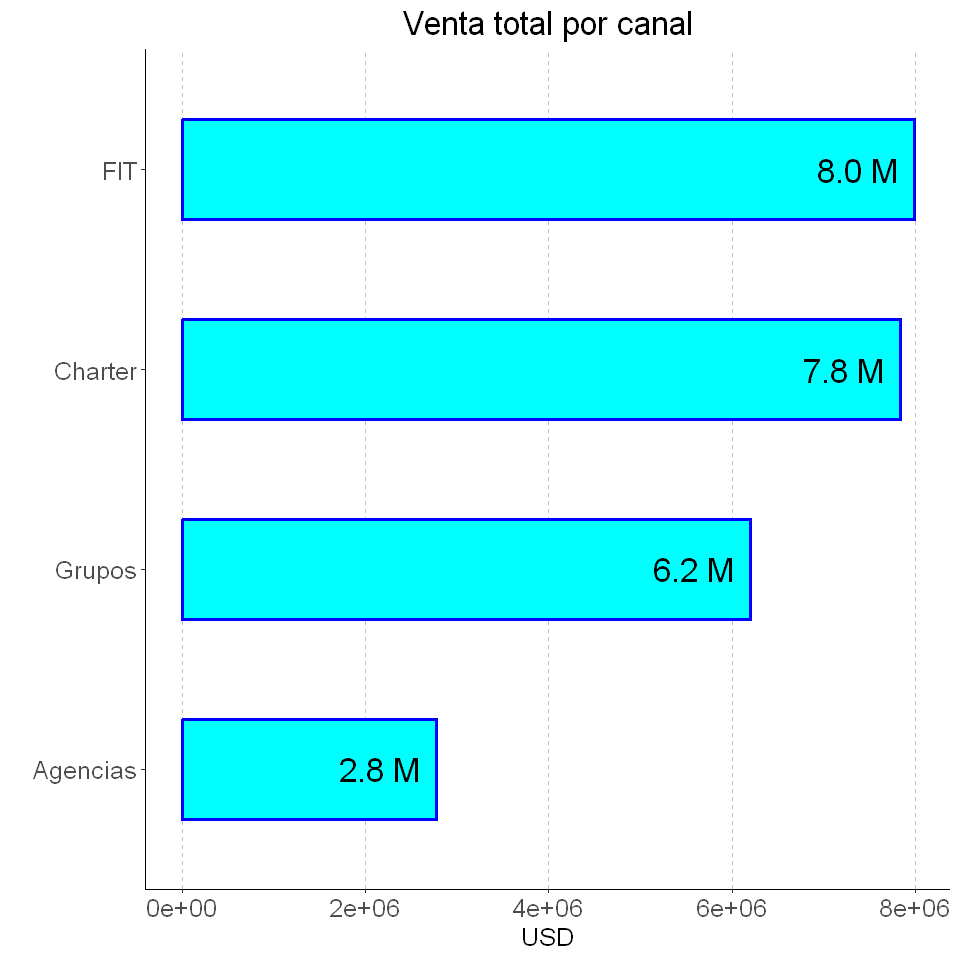

In [28]:
# Crear visualizacion (se incluye formato posterior a conclusiones)
options(repr.plot.width = 8, repr.plot.height = 8)
ggplot(
    data = vta_canal,
    mapping = aes(
        x = reorder(canal, venta_total),
        y = venta_total,
        label = paste(
            formatC(venta_total/1000000, format = "f", digits = 1),
            "M"
        )
    )
) +
geom_col(
    fill = "cyan",
    color = "blue",
    width = 0.5,
    linewidth = 1
) +
geom_text(
    size = 7,
    hjust = 1.2
) +
coord_flip() +
labs(
    title = "Venta total por canal",
    x = "",
    y = "USD"
) +
theme_classic() +
theme(
    panel.grid.major.x = element_line(color = "gray", linetype = "dashed"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15)
)

**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | El canal agencias es el de menor venta total lo cual se explicaría porque la demanda atendida por este canal se asocia a pequeños grupos (generalmente familias o parejas). En cualquier caso se recomendaría que a partir de estos resultados se incentiven las ventas de este canal  en MT ya sea con una mayor inversión de marketing o bien mediante la ampliación del equipo de ventas destinado a este canal. |

## Entendimiento de nuevos datos

Vistos los buenos resultados alcanzados hasta el momento por tu análisis, MT te provee de nueva información constante en el dataset [**paxtours2023.xlsx**](https://github.com/jsaraujo5081/material_curso_data_analytics/raw/refs/heads/main/datasets/pax_tours2023.xlsx).

Carga esta tabla en tu documento con la función `read_excel` de **readxl** considerando que su extensión es *xlsx*, y a continuación mira su estructura.

In [29]:
# Cargar datos
temp_file <- tempfile(fileext = ".xlsx")
download.file("https://github.com/jsaraujo5081/material_curso_data_analytics/raw/refs/heads/main/datasets/pax_tours2023.xlsx", temp_file, mode = "wb")
df_paxtours <- read_excel(temp_file)

In [30]:
# Mirar estructura de los datos
glimpse(df_paxtours)

Rows: 48
Columns: 4
$ canal <chr> "Agencias", "Agencias", "Agencias", "Agencias", "Agencias", "Age…
$ mes   <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9…
$ pax   <dbl> 148, 92, 84, 76, 31, 60, 74, 72, 22, 38, 87, 91, 141, 184, 229, …
$ tours <dbl> 35, 19, 25, 22, 12, 18, 17, 18, 8, 11, 26, 26, 4, 5, 6, 5, 6, 3,…


El dataframe consta de 48 filas y 4 columnas descritas a continuación:

* canal: Tipo de cliente asociado a la ventas del 2023.
* mes: Mes del 2023 en el cual se hizo el viaje.
* pax: Cantidad de pasajeros que correponden a ese canal y mes de venta.
* tours: Cantidad de grupos que correponden a ese canal y mes de venta.

Estudia este dataset y define un plan de acción para procesarlo y posteriormente unirlo satisfactoriamente con la información que ya tienes sobre venta.

In [31]:
# Generar muestra de los datos
df_paxtours %>% sample_n(10)

canal,mes,pax,tours
<chr>,<dbl>,<dbl>,<dbl>
Agencias,8,72,18
Agencias,10,38,11
WS - FIT,7,253,72
WS - Other,3,681,22
WS - Other,11,689,31
Agencias,11,87,26
Charter,5,231,6
WS - FIT,10,205,62
Charter,7,170,5


In [32]:
# Obtener casos únicos de columna canal
df_paxtours["canal"] %>% unique()

canal
<chr>
Agencias
Charter
WS - FIT
WS - Other


In [33]:
# Obtener un resumen estadistico de pax y tours
df_paxtours[c("pax", "tours")] %>% summary()

      pax              tours       
 Min.   :  22.00   Min.   :  1.00  
 1st Qu.:  86.25   1st Qu.:  7.50  
 Median : 194.50   Median : 25.00  
 Mean   : 321.31   Mean   : 35.88  
 3rd Qu.: 396.00   3rd Qu.: 42.00  
 Max.   :1371.00   Max.   :129.00  

**PLAN DE ACCIÓN PARA PREPARACIÓN DE DATOS**

| # | Acción |
| ---- | ---- |
| 1 | Cambiar los valores de la columna canal a fin que se correspondan con los nombres utilizados en los análisis precedentes. |
| 2 | Hacer que los valores de mes se presenten en forma más semántica para que se correspondan con los meses utilizados previamente. |
| 3 | Agregar la información de ventas a niveles de canal y mes para que su detalle sea compatible con la nueva información y puedan unificarse ambas fuentes de datos. |

## Preparación de datos (II)

Pon en marcha el plan de acción definido de manera ordenada y clara.

In [34]:
# Cambiar valores de canal
df_paxtours <- df_paxtours %>%
rowwise %>%
mutate(canal = nombres_canal(canal)) %>%
ungroup()

df_paxtours["canal"] %>% unique()

canal
<chr>
Agencias
Charter
FIT
Grupos


In [35]:
#Ajustar nombres de meses
df_paxtours <- df_paxtours %>%
left_join(cat_mes, by = "mes") %>%
mutate(mes = mes_nombre, .keep = "unused")

df_paxtours["mes"] %>% unique()

mes
<chr>
01.Ene
02.Feb
03.Mar
04.Abr
05.May
06.Jun
07.Jul
08.Ago
09.Sep


In [36]:
# Agregar datos de venta a nivel de canal y mes
df_ventas_ag <- df_ventas_final %>%
group_by(
    canal,
    mes
) %>%
summarise(
    venta_total = sum(venta_total),
    venta_barcos = sum(venta_barcos),
    venta_otros = sum(venta_otros)
) %>%
ungroup()

df_ventas_ag %>% sample_n(5)

`summarise()` has grouped output by 'canal'. You can override using the
`.groups` argument.


canal,mes,venta_total,venta_barcos,venta_otros
<chr>,<chr>,<dbl>,<dbl>,<dbl>
Agencias,10.Oct,72881.85,34003.49,38878.36
Charter,02.Feb,833412.27,606741.60,226670.67
Grupos,09.Sep,201119.45,77588.30,123531.15
Grupos,06.Jun,555853.42,233302.45,322550.97
Agencias,07.Jul,145111.17,25269.99,119841.18


In [37]:
# Unir datos de pax y tours con ventas
df_consolidado <- df_ventas_ag %>%
left_join(
    df_paxtours,
    by = c("canal", "mes")
)

glimpse(df_consolidado)

Rows: 48
Columns: 7
$ canal        <chr> "Agencias", "Agencias", "Agencias", "Agencias", "Agencias…
$ mes          <chr> "01.Ene", "02.Feb", "03.Mar", "04.Abr", "05.May", "06.Jun…
$ venta_total  <dbl> 520203.81, 183789.76, 340510.06, 190679.88, 103764.64, 26…
$ venta_barcos <dbl> 288574.59, 101950.85, 123213.50, 81053.00, 42027.33, 1791…
$ venta_otros  <dbl> 231629.22, 81838.91, 217296.56, 109626.88, 61737.31, 8548…
$ pax          <dbl> 148, 92, 84, 76, 31, 60, 74, 72, 22, 38, 87, 91, 141, 184…
$ tours        <dbl> 35, 19, 25, 22, 12, 18, 17, 18, 8, 11, 26, 26, 4, 5, 6, 5…


Imprime una muestra de tu dataset consolidado para validar que se encuentre listo para el análisis.

In [38]:
df_consolidado %>% sample_n(10)

canal,mes,venta_total,venta_barcos,venta_otros,pax,tours
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FIT,04.Abr,754561.74,399931.28,354630.46,312,111
Charter,09.Sep,168327.19,150940.80,17386.39,29,1
Grupos,07.Jul,744559.04,323687.30,420871.74,966,35
Charter,10.Oct,635380.00,473601.60,161778.40,143,4
Agencias,05.May,103764.64,42027.33,61737.31,31,12
Agencias,10.Oct,72881.85,34003.49,38878.36,38,11
Agencias,02.Feb,183789.76,101950.85,81838.91,92,19
Agencias,04.Abr,190679.88,81053.00,109626.88,76,22
Charter,06.Jun,675195.09,573450.40,101744.69,107,3


## Análisis de datos (II)

Con la nueva información disponible, continúa respondiendo preguntas de negocio.

### ¿Cuál es el comportamiento mensual del precio pagado por pasajero?

In [39]:
# Agregar datos
precio_mes <- df_consolidado %>%
group_by(mes) %>%
summarise(precio = sum(venta_total) / sum(pax)) %>%
ungroup()

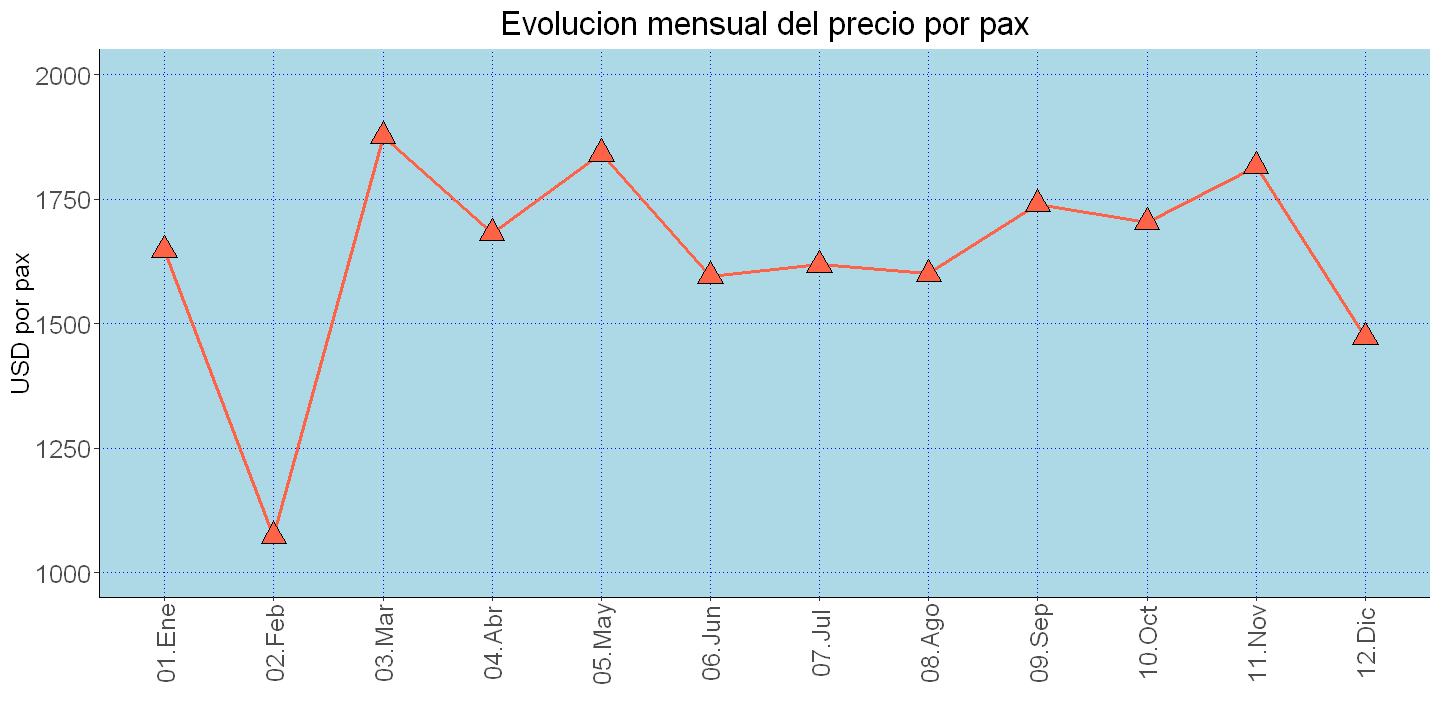

In [40]:
# Generar visualizacion
options(repr.plot.width = 12, repr.plot.height = 6)
ggplot(
    data = precio_mes,
    mapping = aes(
        x = mes,
        y = precio,
        group = 1 # Necesario cuando el eje x no es numerico
    )
) +
geom_line(
    color = "tomato",
    linewidth = 1
) +
geom_point(
    fill = "tomato",
    size = 5,
    pch = 24
) +
labs(
    title = "Evolucion mensual del precio por pax",
    x = "",
    y = "USD por pax"
) +
ylim(c(1000, 2000)) +
theme_classic() +
theme(
    panel.grid.major = element_line(color = "blue", linetype = "dotted"),
    panel.background = element_rect(fill = "lightblue"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15),
    axis.text.x = element_text(angle = 90, vjust = 0.5)
)

**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | La reducción en el precio observado en los meses de febrero y diciembre responderían a la aplicación de políticas de descuentos que compensen una potencial baja demanda esperable en el turismo durante estos momentos del año (temporadas bajas poteriores a feriados de navidad y año nuevo). |

### ¿Cómo se comporta el precio pagado por pasajero por canal?

In [41]:
# Agregar datos
precio_canal <- df_consolidado %>%
group_by(canal) %>%
summarise(precio = sum(venta_total) / sum(pax)) %>%
ungroup()

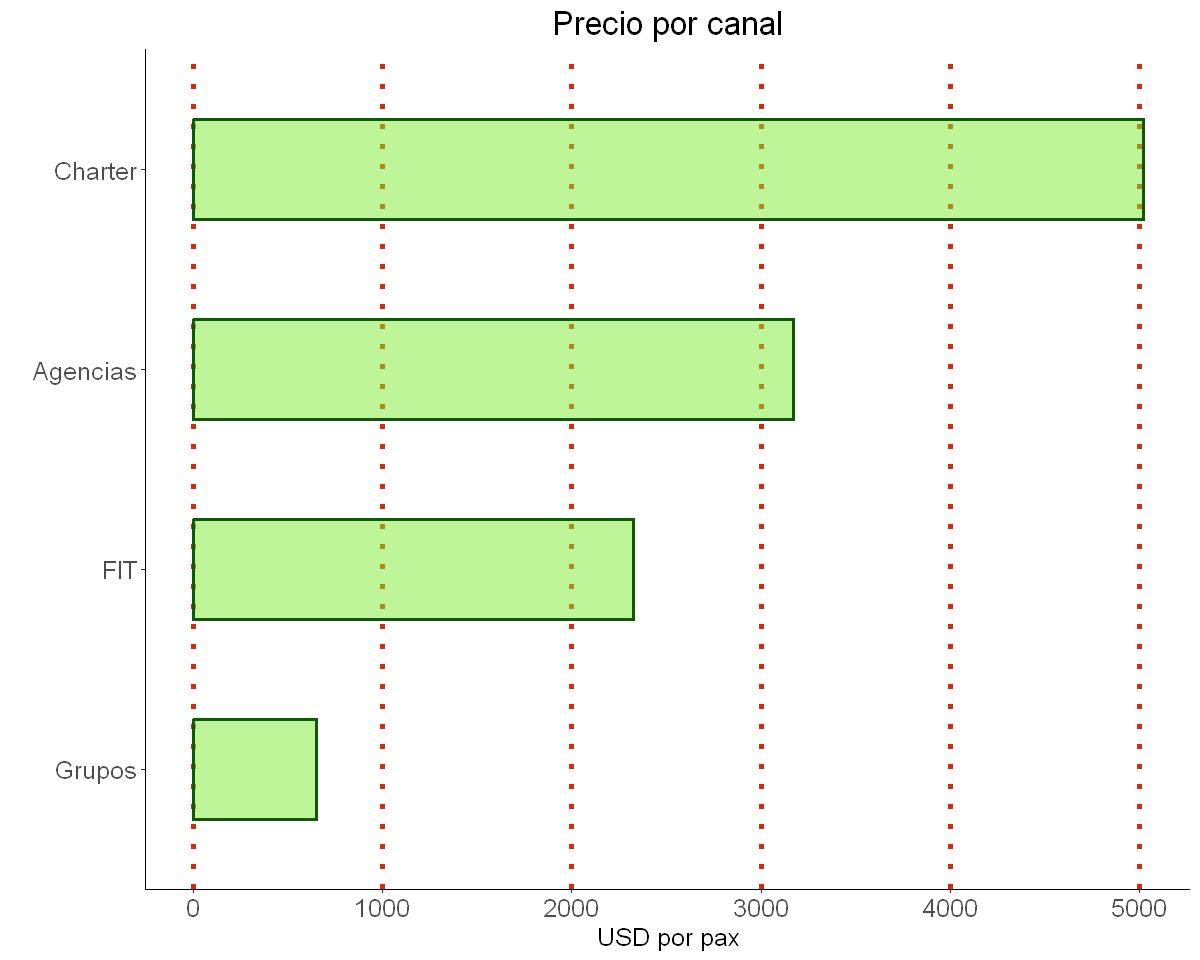

In [42]:
# Generar visualizacion
options(repr.plot.width = 10, repr.plot.height = 8)
ggplot(
    data = precio_canal,
    mapping = aes(
        x = reorder(canal, precio),
        y = precio
    )
) +
geom_col(
    fill = "#7deb34",
    color = "#105908",
    linewidth = 1,
    width = 0.5,
    alpha = 0.5
) +
coord_flip() +
labs(
    title = "Precio por canal",
    x = "",
    y = "USD por pax"
) +
theme_classic() +
theme(
    panel.grid.major.x = element_line(color = "#d62a0f", linetype = "dotted", linewidth = 1.5),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15)
)

**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | Los charters tiene el valor de precio por pasajero más alto lo cual es consistente con la naturaleza de este canal en cuanto MT recibe un pago por la totalidad de las salidas de barcos sin que esto implique una completa ocupación real. De hecho, las salidas de charters tienen en promedio una ocupación de 65%, por lo que cada pasajero representa un valor de 154% del valor real del crucero. |
| 2 | Si bien el canal agencias tiene una baja participación en las ventas totales, el precio por pasajero es mayor que aquellos observados en otros canales. Esto permite inferir su potencial rentabilidad que sustenta aún más la recomendación de generar una mayor inversión para fortalecer sus actividades. |

### ¿Existen diferencias en el año respecto al tamaño de los tours que viajan por el canal Agencias respecto a los FIT? 

Es importante aclarar que "tamaño de tours" hace referencia a la cantidad de pasajeros en cada tour.

In [43]:
# Agregar datos
pax_tours <- df_consolidado %>%
filter(canal %in% c("Agencias", "FIT")) %>%
group_by(
    canal,
    mes
) %>%
summarise(pax_por_tour = sum(pax) / sum(tours)) %>%
ungroup()

`summarise()` has grouped output by 'canal'. You can override using the
`.groups` argument.


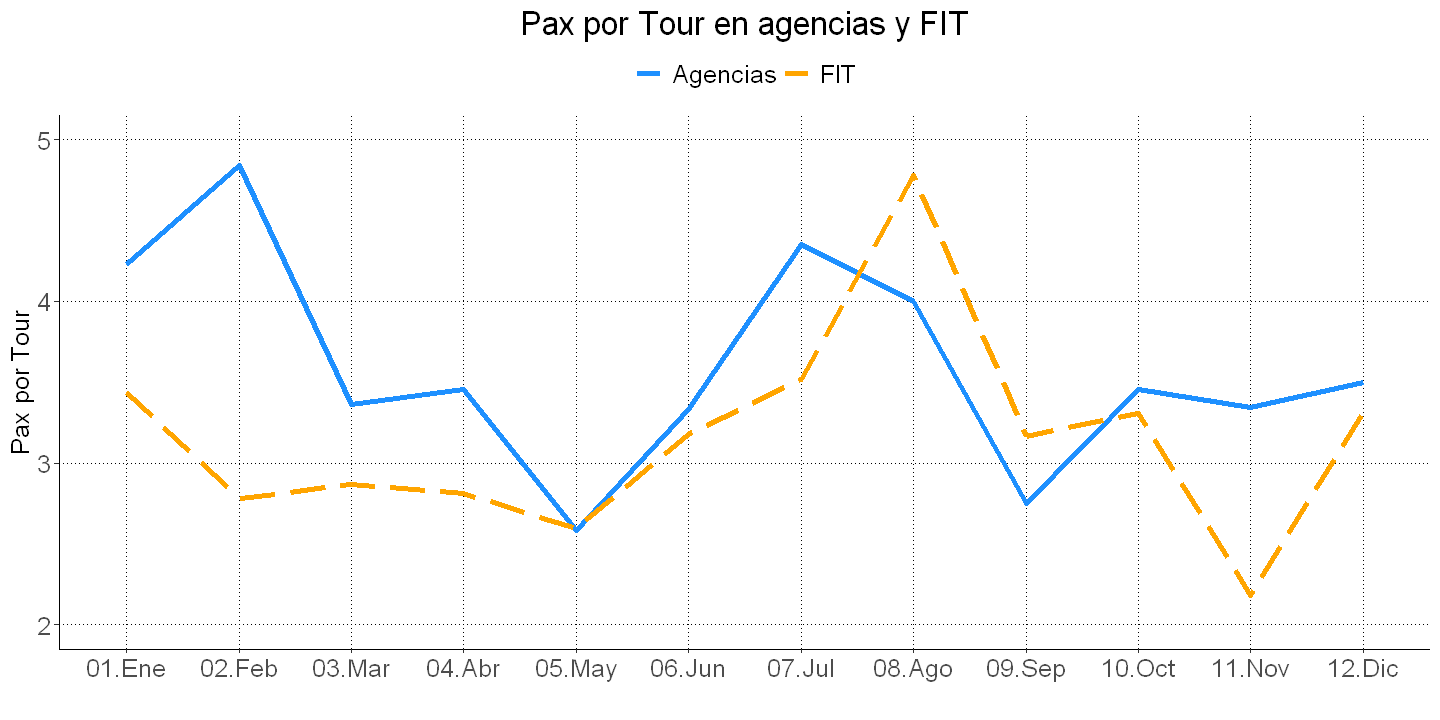

In [44]:
# Generar visualizacion
options(repr.plot.width = 12, repr.plot.height = 6)
ggplot(
    data = pax_tours,
    mapping = aes(
        x = mes,
        y = pax_por_tour,
        group = canal,
        color = canal,
        linetype = canal
    )
) +
geom_line(
    linewidth = 1.5
) +
labs(
    title = "Pax por Tour en agencias y FIT",
    x = "",
    y = "Pax por Tour"
) +
scale_color_manual(values = c("dodgerblue", "orange")) +
scale_linetype_manual(values = c(1,5)) +
scale_y_continuous(breaks = 2:5, limits = c(2,5)) +
theme_classic() +
theme(
    panel.grid.major = element_line(color = "black", linetype = "dotted"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15),
    legend.title = element_blank(),
    legend.text = element_text(size = 15),
    legend.position = "top"
)

**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | Agencias y FIT compiten con mayor intensidad en los meses de verano (Jun - Jul - Ago) en el nicho de viajes "familiares". Lo anterior queda en evidencia al observar que ambos tienen tamaños de grupos similares y con más de 3 pasajeros por tour. |
| 2 | Entre los meses de Febrero y Abril, e igual en Noviembre, El canal FIT tiene un enfoque más asociado a parejas o grupos familares reducidos (con tamaños de grupo cercanos a 2). Por su parte, Agencias sigue atendiendo a mercados familiares. Quizás esto es parte de la explicación del porqué las ventas por este último canal son menores, visto que en períodos de clases en institutos y universidades la demanda por viajes familiares es significativamente menor. |